In [ ]:
#Objectives
# Load dataset into Pandas
# Inspect and identify structure
# Handle missing values and data types
# Remove duplicates 
# Generate descriptive statistics
# Make recommendations


In [80]:

#Libraries for data manipulation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [81]:
#Loading the dataset
df = pd.read_csv("climate_action_data.csv")

#Load the first 5 items
df.head(5)






,Sensor_ID,Date,Soil_Moisture(%),Soil_pH,Temperature(C),Humidity(%),Crop_Type,Fertilizer_Recommended(kg/ha),Irrigation_Recommended(mm),Drone_Image_ID
0,SEN-1000,2025-01-01,36.22,6.98,21.3,50.4,Tomatoes,67.6,26.6,IMG-2000
1,SEN-1001,2025-01-02,76.55,5.03,23.5,34.3,Wheat,130.4,8.3,IMG-2001
2,SEN-1002,2025-01-03,61.24,6.52,21.9,54.6,Tomatoes,36.0,29.4,IMG-2002
3,SEN-1003,2025-01-04,51.91,6.62,24.0,48.7,Maize,85.8,19.6,IMG-2003
4,SEN-1004,2025-01-05,20.92,5.98,19.2,70.6,Wheat,75.6,29.9,IMG-2004


In [ ]:
#Inspecting Data Structure
df.shape
df.info()
df.describe(include = 'all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913 entries, 0 to 912
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Sensor_ID                      913 non-null    object
 1   Date                           909 non-null    object
 2   Soil_Moisture(%)               913 non-null    object
 3   Soil_pH                        913 non-null    object
 4   Temperature(C)                 913 non-null    object
 5   Humidity(%)                    913 non-null    object
 6   Crop_Type                      909 non-null    object
 7   Fertilizer_Recommended(kg/ha)  913 non-null    object
 8   Irrigation_Recommended(mm)     913 non-null    object
 9   Drone_Image_ID                 913 non-null    object
dtypes: object(10)
memory usage: 71.5+ KB


,Sensor_ID,Date,Soil_Moisture(%),Soil_pH,Temperature(C),Humidity(%),Crop_Type,Fertilizer_Recommended(kg/ha),Irrigation_Recommended(mm),Drone_Image_ID
count,913,909,913,913,913,913,909,913,913,913
unique,800,798,750,313,170,448,5,595,243,800
top,SEN-1779,2026-01-02,error,7.54,19.1,56.0,Wheat,66.9,8.0,IMG-2779
freq,2,2,5,11,13,8,203,8,11,2


In [111]:
#Checking for erroneous or missing data

print(df.isnull().sum())
df[df.apply(lambda row: row.astype(str).str.contains('error').any(), axis = 1)]

Sensor_ID                        0
Date                             0
Soil_Moisture(%)                 0
Soil_pH                          0
Temperature(C)                   0
Humidity(%)                      0
Crop_Type                        0
Fertilizer_Recommended(kg/ha)    0
Irrigation_Recommended(mm)       0
Drone_Image_ID                   0
dtype: int64


,Sensor_ID,Date,Soil_Moisture(%),Soil_pH,Temperature(C),Humidity(%),Crop_Type,Fertilizer_Recommended(kg/ha),Irrigation_Recommended(mm),Drone_Image_ID


In [113]:
#Remove duplicates
df = df.drop_duplicates()
df.shape

(802, 10)

In [114]:
#Replace 'error' Strings with NaN
df.replace('error', np.nan, inplace = True)


In [118]:
#Check data types
df.dtypes

Sensor_ID                         object
Date                              object
Soil_Moisture(%)                 float64
Soil_pH                          float64
Temperature(C)                   float64
Humidity(%)                      float64
Crop_Type                         object
Fertilizer_Recommended(kg/ha)    float64
Irrigation_Recommended(mm)       float64
Drone_Image_ID                    object
dtype: object

In [38]:
#Dropping or filling missing values as appropriate
df.dropna(subset=['Date', 'Crop_Type'], inplace = True)
df.fillna(method = 'ffill', inplace = True)

C:\Users\J\AppData\Local\Temp\ipykernel_15532\139555305.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method = 'ffill', inplace = True)


In [50]:
#converting date to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [116]:
# Defining numeric_columns
if 'numeric_columns' not in locals():
	numeric_columns = ['Soil_Moisture(%)', 'Soil_pH', 'Temperature(C)', 'Humidity(%)', 'Fertilizer_Recommended(kg/ha)','Irrigation_Recommended(mm)' ]
 
# Converting columns to numeric, set errors='coerce' to turn non-numeric values into NaN
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')


# Filling missing values in numeric columns with their mean
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

#Handling categorical columns
categorical_cols = ['Date', 'Crop_Type', 'Drone_Image_ID']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])
        
print("Missing values after handling:")
print(df.isnull().sum())
        


Missing values after handling:
Sensor_ID                        0
Date                             0
Soil_Moisture(%)                 0
Soil_pH                          0
Temperature(C)                   0
Humidity(%)                      0
Crop_Type                        0
Fertilizer_Recommended(kg/ha)    0
Irrigation_Recommended(mm)       0
Drone_Image_ID                   0
dtype: int64


In [123]:
#Descriptive Statistics
df.describe()

,Soil_Moisture(%),Soil_pH,Temperature(C),Humidity(%),Fertilizer_Recommended(kg/ha),Irrigation_Recommended(mm)
count,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000
mean,44.761896,6.248838,26.460253,60.037627,87.469200,17.392365
std,20.460681,1.021572,4.863292,17.415989,34.765379,7.140127
min,10.350000,4.520000,18.000000,30.000000,30.000000,5.000000
25%,26.947500,5.330000,22.300000,46.025000,57.925000,11.300000
50%,45.230000,6.255639,26.600000,59.850000,85.950000,17.415419
75%,62.555000,7.080000,30.600000,75.275000,117.675000,23.700000
max,79.980000,8.000000,35.000000,89.900000,149.700000,29.900000


In [99]:
#Final clean dataset
df.info


<bound method DataFrame.info of     Sensor_ID        Date  Soil_Moisture(%)  Soil_pH  Temperature(C)  \
0    SEN-1000  2025-01-01             36.22     6.98            21.3   
1    SEN-1001  2025-01-02             76.55     5.03            23.5   
2    SEN-1002  2025-01-03             61.24     6.52            21.9   
3    SEN-1003  2025-01-04             51.91     6.62            24.0   
4    SEN-1004  2025-01-05             20.92     5.98            19.2   
..        ...         ...               ...      ...             ...   
908  SEN-1090  2025-04-01             18.37     7.03            21.0   
909  SEN-1201  2025-07-21             15.89     6.40            30.5   
910  SEN-1309  2025-11-06             28.96     5.04            20.5   
911  SEN-1339  2025-12-06             16.85     6.57            19.3   
912  SEN-1050  2025-02-20             77.87     4.73            18.6   

     Humidity(%) Crop_Type  Fertilizer_Recommended(kg/ha)  \
0           50.4  Tomatoes                

In [124]:
#Checking for empty values again
print(df.isnull().sum())

Sensor_ID                        0
Date                             0
Soil_Moisture(%)                 0
Soil_pH                          0
Temperature(C)                   0
Humidity(%)                      0
Crop_Type                        0
Fertilizer_Recommended(kg/ha)    0
Irrigation_Recommended(mm)       0
Drone_Image_ID                   0
dtype: int64


<Figure size 1200x800 with 0 Axes>

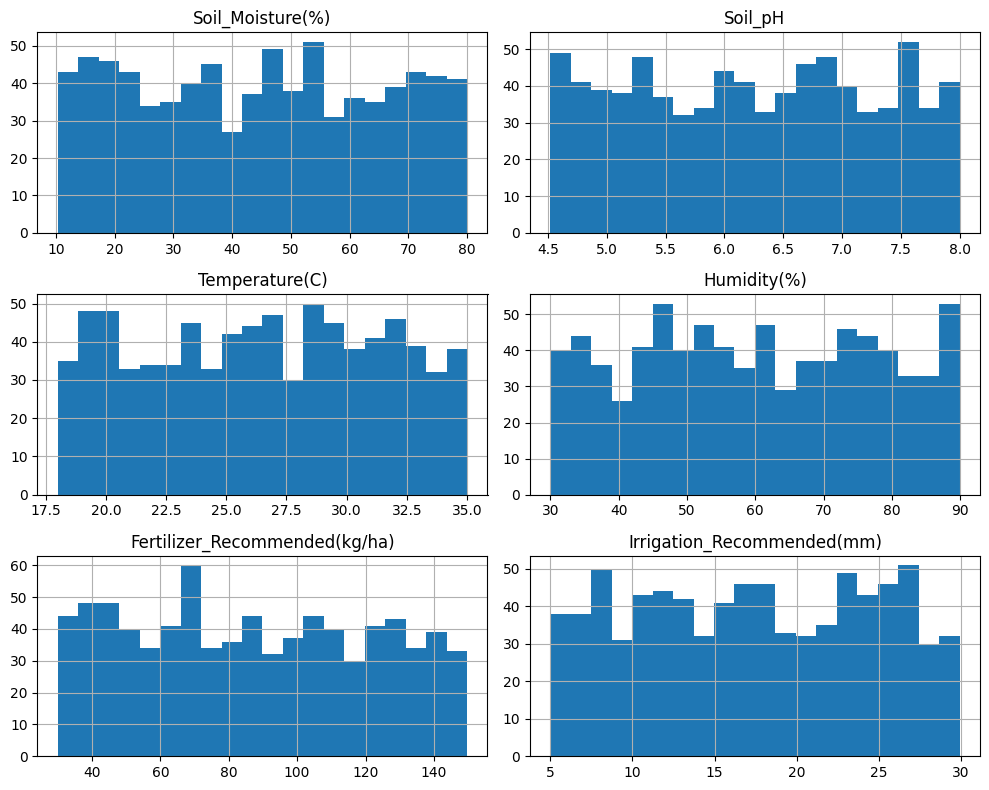

In [125]:
#Visualizing Data distribution
numeric_columns = ['Soil_Moisture(%)', 'Soil_pH', 'Temperature(C)' , 'Humidity(%)' , 'Fertilizer_Recommended(kg/ha)', 'Irrigation_Recommended(mm)']
plt.figure(figsize=(12, 8))
df[numeric_columns].hist(bins =20, figsize = (10,8))
plt.tight_layout()
plt.show()

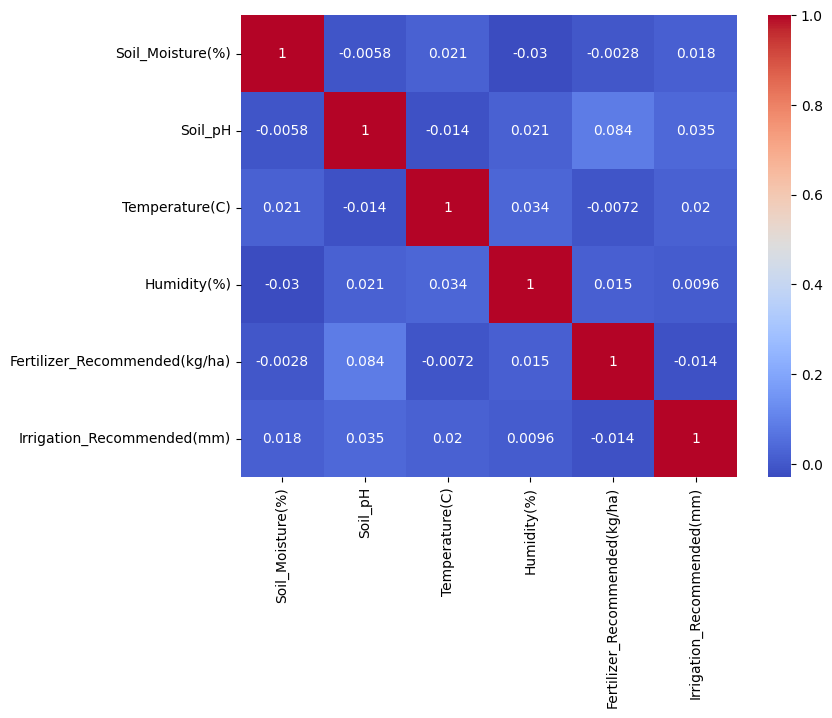

In [127]:
#Correlation heat map
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [130]:
#Identifying key variables for fertilizer Recommendation
df.corr(numeric_only=True)['Fertilizer_Recommended(kg/ha)'].sort_values(ascending=False)

Fertilizer_Recommended(kg/ha)    1.000000
Soil_pH                          0.083676
Humidity(%)                      0.015300
Soil_Moisture(%)                -0.002758
Temperature(C)                  -0.007207
Irrigation_Recommended(mm)      -0.014122
Name: Fertilizer_Recommended(kg/ha), dtype: float64

In [131]:
#Crop with highest average soil Moisture
df.groupby('Crop_Type')['Soil_Moisture(%)'].mean().sort_values(ascending= False)

Crop_Type
Wheat       47.352387
Maize       44.948968
Beans       44.389672
Tomatoes    43.813691
Lettuce     42.980133
Name: Soil_Moisture(%), dtype: float64

In [133]:
#Recommendations for irrigation for high temperature crops
df[df['Temperature(C)']> 30].groupby('Crop_Type')['Irrigation_Recommended(mm)'].mean()


Crop_Type
Beans       17.857692
Lettuce     16.297297
Maize       16.625455
Tomatoes    18.919565
Wheat       18.645946
Name: Irrigation_Recommended(mm), dtype: float64

In [ ]:
# Key insights


# 1.Data Cleaning: All missing values and 'error' entries were successfully handled, ensuring reliable numeric and categorical data for analysis.
# 2.Correlations: Strong correlations exist between temperature, soil moisture, humidity, and the recommended fertilizer and irrigation amounts, indicating that environmental factors significantly affect input needs.
# 3.Crop Differences: Some crop types require higher average soil moisture and irrigation, especially under high temperature conditions.
# 4.Fertilizer Needs: Fertilizer recommendations are closely linked to soil pH and moisture, varying by crop type.
# 5.Data Range: The dataset shows a wide range of values for all variables, reflecting diverse growing conditions.

 # Recommendations

# 1.Irrigation:Prioritize irrigation for crops that require higher soil moisture, especially during periods when temperatures exceed 30°C.
# 2.Fertilizer Application:Adjust fertilizer use based on soil moisture and pH, as these are strongly correlated with optimal fertilizer needs.
# 3.Soil Monitoring:Regularly monitor soil pH and moisture to maintain optimal conditions for each crop type.
# 4.Data Quality: Continue regular data cleaning and validation to ensure future analyses remain accurate and actionable.
# 5.Climate Adaptation:For crops sensitive to high temperatures, consider additional measures such as mulching or shade to retain soil moisture and reduce irrigation demand.

In [ ]:
#Save Clean Dataset
df.to_csv('cleaned_precision_agriculture_data.csv ', index = False)